***Estrutucuración del proyecto***

*Instalar y desplegar librerias*

In [1]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn plotly jupyter prophet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

# Utilidades
import warnings
warnings.filterwarnings('ignore')


*Leer archivos*

In [3]:
from pathlib import Path
import pandas as pd

carpeta = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Productos")
meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
         "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
años = ["2024", "2025", "2026"]

productos = {}
for año in años:
    for mes in meses:
        archivo = f"{mes}-{año}.xlsx"
        ruta = carpeta / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=7)
            productos[f"{mes}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

carpeta_2 = Path(r"C:\Users\andre\OneDrive - Universidad de los Andes\cosas de la universidad\Uniandes\VII\PICE\iPPO\Facturas_lugar")
lugares = ["CP", "Principal"]

factura_lugar = {}
for año in años:
    for lugar in lugares:
        archivo = f"{lugar}-{año}.xlsx"
        ruta = carpeta_2 / archivo
        if not ruta.exists():
            print(f"No encontrado: {archivo}")
            continue
        try:
            df = pd.read_excel(ruta, header=6)
            factura_lugar[f"{lugar}-{año}"] = df
        except PermissionError:
            print(f"Permiso denegado (¿está abierto en Excel?): {archivo}")
            continue

print("Productos cargados:", list(productos.keys()))
print("Facturas lugar cargadas:", list(factura_lugar.keys()))


No encontrado: Enero-2024.xlsx
No encontrado: Febrero-2024.xlsx
No encontrado: Marzo-2024.xlsx
No encontrado: Abril-2024.xlsx
No encontrado: Mayo-2024.xlsx
No encontrado: Junio-2024.xlsx
No encontrado: Julio-2024.xlsx
No encontrado: Marzo-2026.xlsx
No encontrado: Abril-2026.xlsx
No encontrado: Mayo-2026.xlsx
No encontrado: Junio-2026.xlsx
No encontrado: Julio-2026.xlsx
No encontrado: Agosto-2026.xlsx
No encontrado: Septiembre-2026.xlsx
No encontrado: Octubre-2026.xlsx
No encontrado: Noviembre-2026.xlsx
No encontrado: Diciembre-2026.xlsx
No encontrado: CP-2024.xlsx
No encontrado: Principal-2024.xlsx
No encontrado: CP-2026.xlsx
No encontrado: Principal-2026.xlsx
Productos cargados: ['Agosto-2024', 'Septiembre-2024', 'Octubre-2024', 'Noviembre-2024', 'Diciembre-2024', 'Enero-2025', 'Febrero-2025', 'Marzo-2025', 'Abril-2025', 'Mayo-2025', 'Junio-2025', 'Julio-2025', 'Agosto-2025', 'Septiembre-2025', 'Octubre-2025', 'Noviembre-2025', 'Diciembre-2025', 'Enero-2026', 'Febrero-2026']
Facturas 

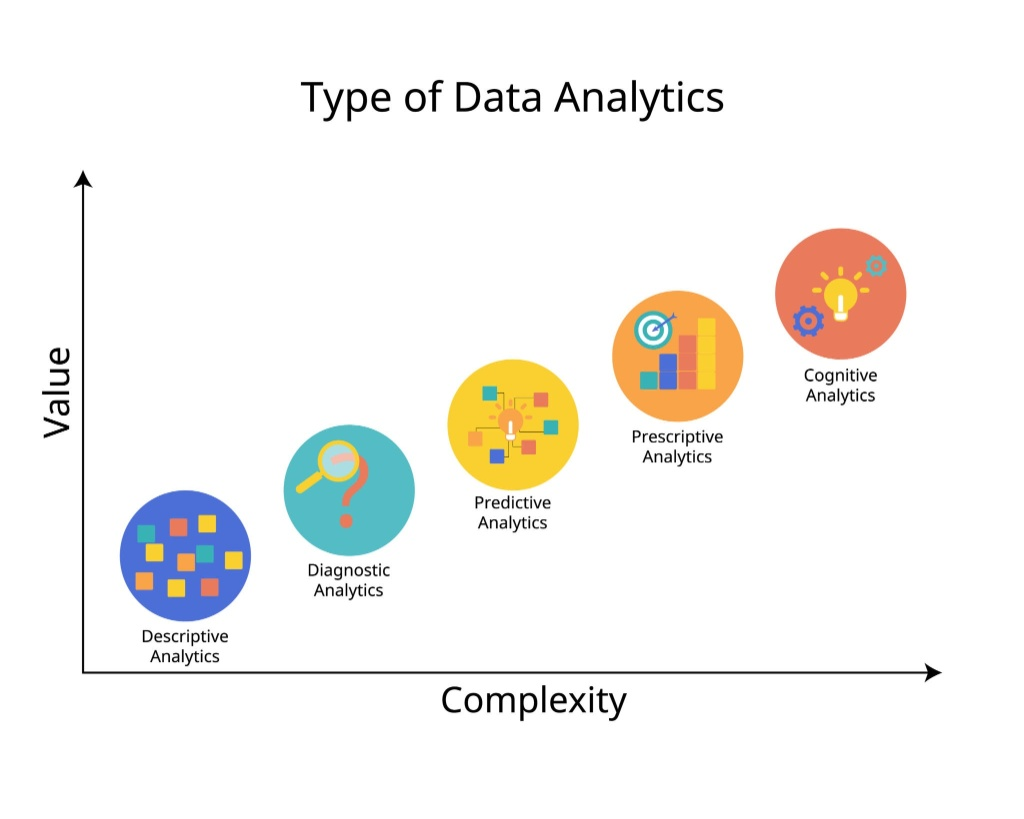

*Verificar fechas de los acrhivos*

In [4]:
col_fecha = "Fecha elaboración"
for mes, df in productos.items():
    df[col_fecha] = pd.to_datetime(df[col_fecha], dayfirst=True, errors="coerce")
    inicio = df[col_fecha].min()
    fin = df[col_fecha].max()
    print(f"{mes}: {inicio.date()} → {fin.date()}")



Agosto-2024: 2024-08-03 → 2024-08-30
Septiembre-2024: 2024-09-06 → 2024-09-24
Octubre-2024: 2024-10-04 → 2024-10-21
Noviembre-2024: 2024-11-25 → 2024-11-25
Diciembre-2024: 2024-12-04 → 2024-12-12
Enero-2025: 2025-01-08 → 2025-01-31
Febrero-2025: 2025-02-01 → 2025-02-28
Marzo-2025: 2025-03-02 → 2025-03-31
Abril-2025: 2025-04-01 → 2025-04-30
Mayo-2025: 2025-05-01 → 2025-05-31
Junio-2025: 2025-06-03 → 2025-06-30
Julio-2025: 2025-07-01 → 2025-07-31
Agosto-2025: 2025-08-04 → 2025-08-31
Septiembre-2025: 2025-09-01 → 2025-09-30
Octubre-2025: 2025-10-01 → 2025-10-31
Noviembre-2025: 2025-11-04 → 2025-11-30
Diciembre-2025: 2025-12-01 → 2025-12-31
Enero-2026: 2026-01-07 → 2026-01-31
Febrero-2026: 2026-02-02 → 2026-02-28


*Crear un df unificado*

In [5]:
df_total = pd.concat(productos.values(), ignore_index=True)


*Concatenar df de ventas por lugar*

In [6]:

#Concatenar en caso de tener mas datos
CP_df=factura_lugar["CP-2025"]
Principal_df=factura_lugar["Principal-2025"]

#Poner el lugar en cada df
CP_df["Lugar"]="CP"
Principal_df["Lugar"]="Principal"

#Unificar todo en un solo df
df_place=pd.concat([CP_df,Principal_df],ignore_index=True)



*Ver que datos tiene cada df*

In [7]:
col1=set(df_total.columns)
col2=set(df_place.columns)

#Mirar intersescciones
print(col1 - col2)#Esta en  total
print(col2 - col1)#Esta en places
print(col2 & col1)#Esta en ambos


{'Valor Impuesto Retención', 'Factura proveedor', 'Nombre vendedor', 'Fecha creación', 'Base AIU', 'Valor unitario', 'Impuesto Cargo 2', 'Valor Impuesto Cargo 2', 'Cantidad', 'Valor desc.', 'Impuesto cargo', 'Cargo en totales', 'Identificación Vendedor', 'Valor Impuesto Cargo', 'Referencia fábrica', 'Impuesto retención', 'Tipo de registro', 'Nombre tercero', 'Nombre', 'Sucursal', 'Identificación', 'Consecutivo', 'Tasa de cambio', 'Bodega', 'Base retención (ICA/IVA)', 'Forma pago', 'Código', 'Centro costo', 'Descuento en totales', 'Nombre contacto', 'Tipo clasificación', 'Fecha vencimiento', 'Número comprobante', 'Fecha elaboración', 'Observaciones', 'Tipo transacción', 'Correo electrónico', 'Fecha modificación'}
{'Pagos en línea', 'Crédito', 'Tipo de comprobante', 'Estado', 'Nro. de comprobante', 'Nro. de identificación', 'Vendedor', 'Fecha y hora', 'Cliente', 'Otros', 'Lugar', 'Efectivo', 'Turno', 'Tarjetas'}
{'Total'}


*Adaptar datos por factura*

In [8]:
#Ventas
df_ventas_producto=df_total[df_total["Tipo transacción"]=="Factura de venta"]
df_ventas_producto = df_ventas_producto.reset_index(drop=True)

variables_iniciales=["Consecutivo","Fecha creación","Tipo de registro","Tipo clasificación","Código","Nombre","Nombre vendedor",\
                     "Cantidad","Valor unitario","Valor Impuesto Cargo","Total","Forma pago","Número comprobante"]
df_ventas_producto_filtrado=df_ventas_producto[variables_iniciales]

df_ventas_producto_filtrado['Establecimiento'] = df_ventas_producto_filtrado['Número comprobante'].map({'FV-1': 'Principal',"FV-2":"Eventos","FV-3":"Eventos",'FV-4': 'CP'})

#Compras
df_compras_producto=df_total[df_total["Tipo transacción"]=="Factura de compra"]
variables_compras=["Consecutivo","Factura proveedor","Identificación","Nombre tercero","Fecha creación","Fecha modificación","Fecha elaboración","Nombre contacto"\
    ,"Tipo de registro","Tipo clasificación","Código","Nombre","Cantidad","Valor unitario","Total","Forma pago","Fecha vencimiento"]

df_compras_producto_filtrado=df_compras_producto[variables_compras]


*Poner fecha en formato datetime*

In [9]:

df_ventas_producto_filtrado['Fecha creación'] = pd.to_datetime(df_ventas_producto_filtrado
                                                               ['Fecha creación'], format='%d/%m/%Y')

fechas = ["Fecha creación", "Fecha modificación", "Fecha elaboración", "Fecha vencimiento"]
df_compras_producto_filtrado[fechas] = df_compras_producto_filtrado[fechas].apply(
    pd.to_datetime, format='%d/%m/%Y'
)


*Poner como se pago cada transacción y otras cosas*

In [10]:
#Poner el tipo de transacción de cda fila 
df_ventas_producto_filtrado["Forma pago"]=df_ventas_producto_filtrado["Forma pago"].bfill()
df_compras_producto_filtrado["Forma pago"]=df_compras_producto_filtrado["Forma pago"].bfill()
#Eliminar las filas que hacian referencia al metodo de pago
df_ventas_producto_filtrado.dropna(subset=["Código"],inplace=True)
df_compras_producto_filtrado.dropna(subset=["Código"],inplace=True)


In [11]:
df_ventas_producto_filtrado.drop(columns=["Tipo de registro","Tipo clasificación"],inplace=True)


In [12]:
ventas=df_ventas_producto_filtrado
ventas.rename(columns={"Fecha creación":"Fecha"},inplace=True)
ventas


,Consecutivo,Fecha,Código,Nombre,Nombre vendedor,Cantidad,Valor unitario,Valor Impuesto Cargo,Total,Forma pago,Número comprobante,Establecimiento
0,401.0,2024-08-30,11,Sándwich o pockets (Mini chef),Tatiana Perez,1.0,12962.96,1037.04,14000.0,Tarjeta Débito,FV-1,Principal
1,401.0,2024-08-30,28,Ensalada Pollo miel mostaza Mediana,Tatiana Perez,1.0,18518.52,1481.48,20000.0,Tarjeta Débito,FV-1,Principal
2,401.0,2024-08-30,38,Arma tu plato mediano (18k),Tatiana Perez,1.0,20370.37,1629.63,22000.0,Tarjeta Débito,FV-1,Principal
3,401.0,2024-08-30,66,Pancakes chocolate,Tatiana Perez,1.0,8888.89,711.11,9600.0,Tarjeta Débito,FV-1,Principal
5,402.0,2024-08-30,B0002,Agua cristal,Tatiana Perez,1.0,2777.78,222.22,3000.0,Efectivo,FV-1,Principal
...,...,...,...,...,...,...,...,...,...,...,...,...
32080,896.0,2026-02-02,16,Bowl Colombianito Mediana,Juan Jose Yara Vallejo,1.0,19444.44,1555.56,21000.0,Nequí,FV-4,CP
32081,896.0,2026-02-02,27,Ensalada Chefsito Grande,Juan Jose Yara Vallejo,1.0,22222.22,1777.78,24000.0,Nequí,FV-4,CP
32082,896.0,2026-02-02,79,Americano Mediano,Juan Jose Yara Vallejo,2.0,4166.66,666.67,9000.0,Nequí,FV-4,CP
32083,896.0,2026-02-02,21025,Mexi,Juan Jose Yara Vallejo,1.0,18500.00,0.00,18500.0,Nequí,FV-4,CP


In [13]:
compras=compras = pd.read_csv('compras.csv')


In [14]:
ventas["Periodo"] = pd.to_datetime(ventas["Fecha"]).dt.to_period("M")


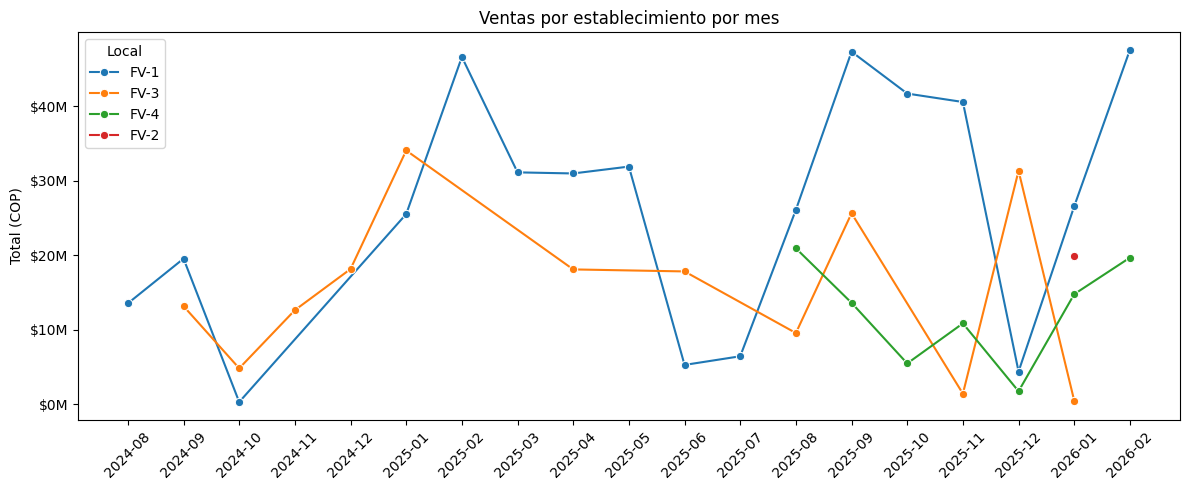

In [15]:

resumen = (
    ventas
    .groupby(["Periodo", "Número comprobante"])["Total"]
    .sum()
    .reset_index()
)

resumen["Periodo"] = resumen["Periodo"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=resumen,
    x="Periodo",
    y="Total",
    hue="Número comprobante",
    marker="o"              # ← agrega puntos en cada mes
)
plt.xticks(rotation=45)
plt.title("Ventas por establecimiento por mes")
plt.ylabel("Total (COP)")
plt.xlabel("")
plt.legend(title="Local")  # ← título más claro en la leyenda

# Formato en millones en el eje Y
import matplotlib.ticker as mticker
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.tight_layout()
plt.show()


In [16]:
import pandas as pd
import plotly.express as px

# 1. Resumen de ventas
resumen_mes = (
    ventas
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)

# Convertir a string es vital para que no lo trate como fecha continua
resumen_mes["Periodo"] = resumen_mes["Periodo"].astype(str)

# 2. Gráfico interactivo
fig = px.bar(
    resumen_mes, 
    x="Periodo", 
    y="Total",
    title="Análisis de Ventas por Periodo",
    labels={"Total": "Monto ($)", "Periodo": "Mes"},
    text_auto='.2s', 
    color_discrete_sequence=["steelblue"]
)

# 3. Personalización estética (Aquí forzamos que aparezcan todos los meses con datos)
fig.update_layout(
    xaxis_tickangle=-45,
    # ESTA LÍNEA ES LA QUE ELIMINA LOS HUECOS VACÍOS COMO DICIEMBRE:
    xaxis_type='category', 
    yaxis_tickformat="$.2s", # Cambiado a .2s para que el eje diga $80M en lugar de $80,000,000
    hovermode="x unified",
    template="plotly_white"
)

# 4. Mostrar el gráfico
fig.show()


In [17]:
import plotly.express as px

# 1. Preparación (Asegúrate de convertir el periodo a texto para evitar los huecos)
resumen_compras_mes = (
    compras
    .groupby("Periodo")["Total"]
    .sum()
    .reset_index()
)
resumen_compras_mes["Periodo"] = resumen_compras_mes["Periodo"].astype(str)

# 2. Gráfico
fig = px.bar(
    resumen_compras_mes, 
    x="Periodo", 
    y="Total",
    title="Total Compras por Periodo",
    color_discrete_sequence=["#CD5C5C"] # Rojo similar al de tu imagen
)

# 3. El truco para quitar los huecos y poner el formato $18M
fig.update_layout(
    template="plotly_white",
    xaxis_tickangle=-45,
    # ESTA LÍNEA QUITA LOS HUECOS:
    xaxis_type='category', 
    # ESTA LÍNEA PONE EL FORMATO $18M:
    yaxis_tickformat="$.2s", 
    hovermode="x unified"
)

# Personalizar el texto al pasar el mouse
fig.update_traces(
    hovertemplate="<b>Periodo:</b> %{x}<br><b>Total:</b> $%{y:,.0f}"
)

fig.show()


In [18]:
ventas_compras = resumen_mes.merge(
    resumen_compras_mes, 
    on="Periodo", 
    how="outer",
    suffixes=("_ventas", "_compras")
)

ventas_compras = ventas_compras.fillna(0)
ventas_compras["Utilidad"] = ventas_compras["Total_ventas"] - ventas_compras["Total_compras"]
ventas_compras = ventas_compras.sort_values("Periodo").reset_index(drop=True)

print(ventas_compras[["Periodo", "Total_ventas", "Total_compras", "Utilidad"]])


    Periodo  Total_ventas  Total_compras     Utilidad
0   2024-08   13552500.00     17591988.0  -4039488.00
1   2024-09   32727310.00            0.0  32727310.00
2   2024-10    5174300.00            0.0   5174300.00
3   2024-11   12644600.00            0.0  12644600.00
4   2024-12   18159161.00            0.0  18159161.00
5   2025-01   59576997.17      4249653.0  55327344.17
6   2025-02   46580484.50      3089645.0  43490839.50
7   2025-03   31114572.00      3692100.0  27422472.00
8   2025-04   49071040.40      4949213.0  44121827.40
9   2025-05   31888620.00      5764664.0  26123956.00
10  2025-06   23134199.26      2863814.0  20270385.26
11  2025-07    6460500.00      6150784.0    309716.00
12  2025-08   56603715.00      5242819.0  51360896.00
13  2025-09   86547085.00      9624248.0  76922837.00
14  2025-10   47174155.00      4496786.0  42677369.00
15  2025-11   52863172.00      5109383.0  47753789.00
16  2025-12   37505122.90      2227879.0  35277243.90
17  2026-01   61709036.00   

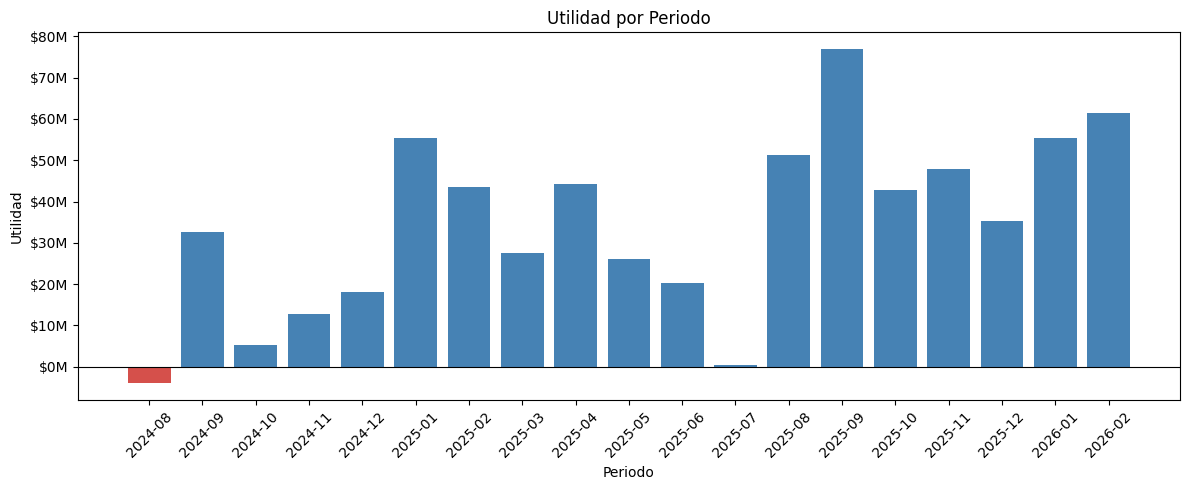

In [19]:
plt.figure(figsize=(12, 5))
plt.bar(ventas_compras["Periodo"], ventas_compras["Utilidad"], 
        color=["#d5504b" if x < 0 else "steelblue" for x in ventas_compras["Utilidad"]])
plt.title("Utilidad por Periodo")
plt.xlabel("Periodo")
plt.ylabel("Utilidad")
plt.xticks(rotation=45)
plt.axhline(y=0, color="black", linewidth=0.8)
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)
plt.tight_layout()
plt.show()


# Analisis productos



In [20]:
ventas_p=ventas[(ventas["Establecimiento"]=="Principal")&(ventas["Fecha"]>="2025-01-01")].sort_values("Fecha",ascending=True).reset_index()
dataset_p=ventas_p[["Fecha","Nombre","Cantidad","Total"]]


In [21]:
info_productos = dataset_p.groupby("Nombre").apply(lambda x: pd.Series({
    "transacciones": x["Nombre"].count(),
    "cantidad_total": x["Cantidad"].sum(),
    "precio_promedio": x["Total"].sum() / x["Cantidad"].sum(),
    "Plata generada":x["Total"].sum()
    
})).sort_values("transacciones", ascending=False)


In [22]:
# Definimos los puntos de corte
corte_x = info_productos["cantidad_total"].median()
corte_y = info_productos["Plata generada"].median()

# Función para asignar el color/categoría
def clasificar(row):
    if row["cantidad_total"] >= corte_x and row["Plata generada"] >= corte_y:
        return "ESTRELLA (Alto Vol / Alto $)"
    elif row["cantidad_total"] < corte_x and row["Plata generada"] >= corte_y:
        return "PREMIUM (Bajo Vol / Alto $)"
    elif row["cantidad_total"] >= corte_x and row["Plata generada"] < corte_y:
        return "GANCHO (Alto Vol / Bajo $)"
    else:
        return "BAJO DESEMPEÑO"

# Aplicamos la lógica al DataFrame
info_productos["Categoria_Matriz"] = info_productos.apply(clasificar, axis=1)

# ── Conteo por cuadrante ──────────────────────────────────────────────────────
conteos = info_productos["Categoria_Matriz"].value_counts()
n_estrella = conteos.get("ESTRELLA (Alto Vol / Alto $)", 0)
n_premium  = conteos.get("PREMIUM (Bajo Vol / Alto $)", 0)
n_gancho   = conteos.get("GANCHO (Alto Vol / Bajo $)", 0)
n_bajo     = conteos.get("BAJO DESEMPEÑO", 0)

import plotly.express as px

fig = px.scatter(
    info_productos.reset_index(), 
    x="cantidad_total", 
    y="Plata generada",
    color="Categoria_Matriz",
    color_discrete_map={
        "ESTRELLA (Alto Vol / Alto $)": "#2ecc71",
        "PREMIUM (Bajo Vol / Alto $)": "#3498db",
        "GANCHO (Alto Vol / Bajo $)": "#f1c40f",
        "BAJO DESEMPEÑO": "#e74c3c"
    },
    hover_name="Nombre",
    log_x=True, 
    log_y=True,
    hover_data=["precio_promedio", "transacciones"],
    title="Dashboard de Estrategia de Productos",
    template="plotly_white"
)

fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='white')))
fig.add_vline(x=corte_x, line_dash="dot", line_color="gray", opacity=0.5)
fig.add_hline(y=corte_y, line_dash="dot", line_color="gray", opacity=0.5)

# ── Anotaciones en las 4 esquinas ─────────────────────────────────────────────
anotaciones = [
    dict(x=0.99, y=0.99, text=f"<b> {n_estrella} productos</b>",
         font=dict(color="#27ae60", size=12),
         xanchor="right", yanchor="top"),
    dict(x=0.01, y=0.99, text=f"<b> {n_premium} productos</b>",
         font=dict(color="#2980b9", size=12),
         xanchor="left", yanchor="top"),
    dict(x=0.99, y=0.01, text=f"<b> {n_gancho} productos</b>",
         font=dict(color="#d4ac0d", size=12),
         xanchor="right", yanchor="bottom"),
    dict(x=0.01, y=0.01, text=f"<b> {n_bajo} productos</b>",
         font=dict(color="#c0392b", size=12),
         xanchor="left", yanchor="bottom"),
]

for a in anotaciones:
    fig.add_annotation(
        x=a["x"], y=a["y"],
        text=a["text"],
        showarrow=False,
        font=a["font"],
        xref="paper", yref="paper",
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="lightgray",
        borderwidth=1,
        borderpad=6,
        xanchor=a["xanchor"],
        yanchor=a["yanchor"],
    )

fig.update_layout(
    legend_title_text='Categoría de Negocio',
    font=dict(family="Verdana", size=12)
)

fig.show()


In [23]:
info_productos=info_productos.reset_index()


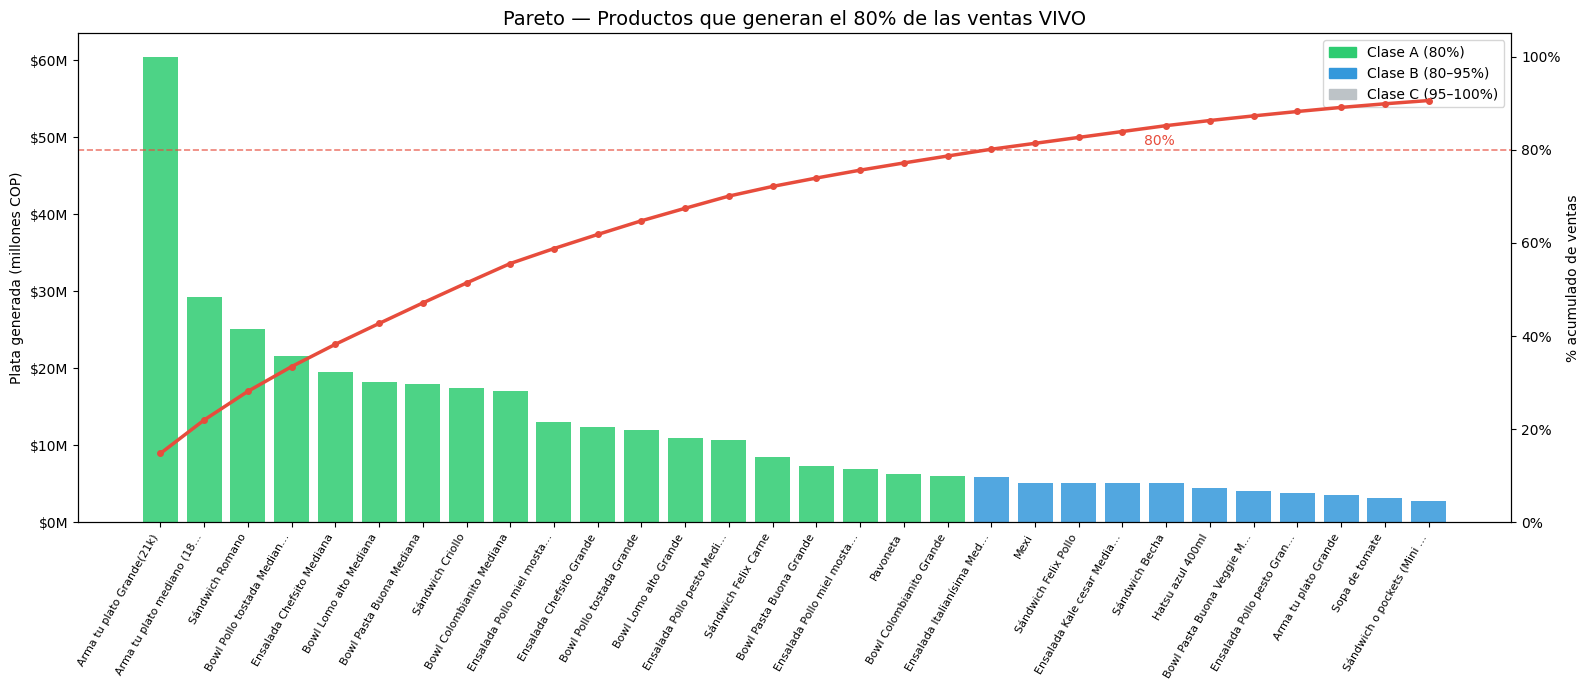


Resumen ABC:
Clase_ABC
C    37
B    21
A    19
Name: count, dtype: int64

Productos Clase A: 19
Plata generada Clase A: $320,704,951


In [24]:
# ── PASO 1: ordenar PRIMERO ───────────────────────────────────────
info_productos=info_productos[info_productos["Categoria_Matriz"]=="ESTRELLA (Alto Vol / Alto $)"]
info_productos = info_productos.sort_values('Plata generada', ascending=False).reset_index(drop=True)



# ── PASO 2: calcular pct DESPUÉS de ordenar ───────────────────────

total = info_productos['Plata generada'].sum()

info_productos['pct']      = info_productos['Plata generada'] / total

info_productos['pct_acum'] = info_productos['pct'].cumsum()



# ── PASO 3: clasificar ABC ────────────────────────────────────────

condiciones = [

    info_productos['pct_acum'] <= 0.80,

    info_productos['pct_acum'] <= 0.95,

]

info_productos['Clase_ABC'] = np.select(condiciones, ['A', 'B'], default='C')



# ── PASO 4: graficar ──────────────────────────────────────────────

n_mostrar = min(30, len(info_productos))

df_plot   = info_productos.head(n_mostrar)



colores = df_plot['Clase_ABC'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})



fig, ax1 = plt.subplots(figsize=(16, 7))



# Barras — plata generada

ax1.bar(range(n_mostrar), df_plot['Plata generada'] / 1_000_000, color=colores, alpha=0.85)

ax1.set_ylabel('Plata generada (millones COP)')

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))



# Línea acumulada (eje derecho)

ax2 = ax1.twinx()

ax2.plot(range(n_mostrar), df_plot['pct_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)

ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)

ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de ventas')

ax2.set_ylim(0, 105)

ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))



# Etiquetas eje X

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]

ax1.set_xticks(range(n_mostrar))

ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)



# Leyenda

leyenda = [

    Patch(color='#2ecc71', label='Clase A (80%)'),

    Patch(color='#3498db', label='Clase B (80–95%)'),

    Patch(color='#bdc3c7', label='Clase C (95–100%)'),

]

ax1.legend(handles=leyenda, loc='upper right')



plt.title('Pareto — Productos que generan el 80% de las ventas VIVO', fontsize=14)

plt.tight_layout()

plt.show()



print(f"\nResumen ABC:")

print(info_productos['Clase_ABC'].value_counts())

print(f"\nProductos Clase A: {(info_productos['Clase_ABC'] == 'A').sum()}")

print(f"Plata generada Clase A: ${info_productos[info_productos['Clase_ABC']=='A']['Plata generada'].sum():,.0f}")


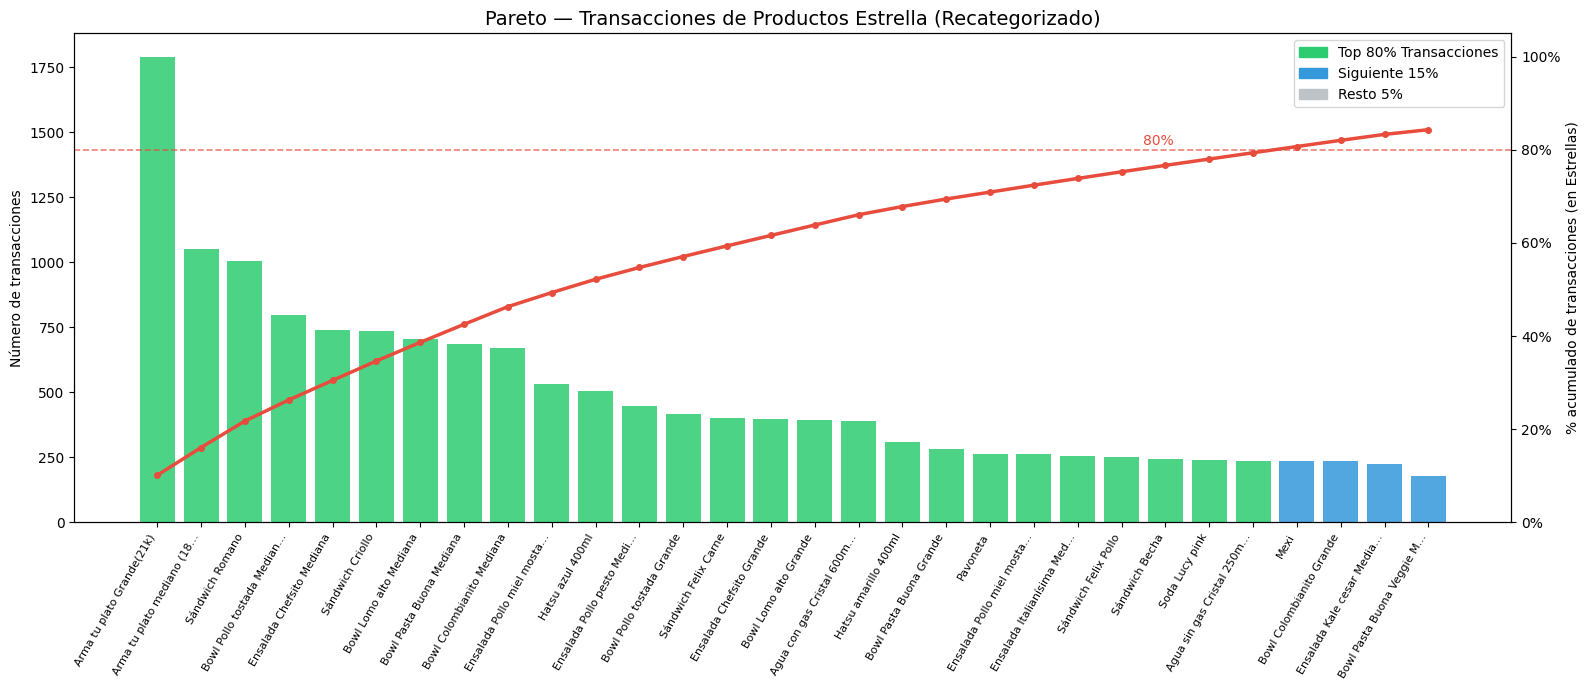

In [25]:
# 1. Filtrar solo los productos Estrella
df_estrella = info_productos[info_productos["Categoria_Matriz"] == "ESTRELLA (Alto Vol / Alto $)"].copy()

# 2. Ordenar por transacciones de mayor a menor
df_estrella = df_estrella.sort_values('transacciones', ascending=False).reset_index(drop=True)

# 3. Recalcular porcentajes sobre este nuevo total
total_trans_estrella = df_estrella['transacciones'].sum()
df_estrella['pct_trans']      = df_estrella['transacciones'] / total_trans_estrella
df_estrella['pct_trans_acum'] = df_estrella['pct_trans'].cumsum()

# 4. RECATEGORIZAR ABC (Solo para este grupo)
# Esto hará que los más vendidos de este grupo salgan en verde (A)
condiciones_estrella = [
    df_estrella['pct_trans_acum'] <= 0.80,
    df_estrella['pct_trans_acum'] <= 0.95,
]
df_estrella['Clase_ABC_Estrella'] = np.select(condiciones_estrella, ['A', 'B'], default='C')

# 5. Configurar visualización
n_mostrar = min(30, len(df_estrella))
df_plot = df_estrella.head(n_mostrar).copy()
colores = df_plot['Clase_ABC_Estrella'].map({'A': '#2ecc71', 'B': '#3498db', 'C': '#bdc3c7'})

# ── GRAFICAR ──────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(16, 7))
ax1.bar(range(n_mostrar), df_plot['transacciones'], color=colores, alpha=0.85)
ax1.set_ylabel('Número de transacciones')

ax2 = ax1.twinx()
ax2.plot(range(n_mostrar), df_plot['pct_trans_acum'] * 100, color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
ax2.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.text(n_mostrar * 0.75, 81, '80%', color='#e74c3c', fontsize=10)

ax2.set_ylabel('% acumulado de transacciones (en Estrellas)')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

nombres_cortos = [nombre[:25] + '…' if len(nombre) > 25 else nombre for nombre in df_plot['Nombre']]
ax1.set_xticks(range(n_mostrar))
ax1.set_xticklabels(nombres_cortos, rotation=60, ha='right', fontsize=8)

leyenda = [
    Patch(color='#2ecc71', label='Top 80% Transacciones'), 
    Patch(color='#3498db', label='Siguiente 15%'), 
    Patch(color='#bdc3c7', label='Resto 5%')
]
ax1.legend(handles=leyenda, loc='upper right')

plt.title('Pareto — Transacciones de Productos Estrella (Recategorizado)', fontsize=14)
plt.tight_layout()
plt.show()


In [26]:
# 1. Extraer nombres de los Clase A de Ventas y de Transacciones (del segmento Estrella)
set_plata = set(info_productos[info_productos['Clase_ABC'] == 'A']['Nombre'])
set_trans = set(df_estrella[df_estrella['Clase_ABC_Estrella'] == 'A']['Nombre'])

# 2. Encontrar los que están en AMBOS (Intersección)
productos_criticos = list(set_plata.intersection(set_trans))

# 3. Crear el DataFrame final de productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)].copy()

print(f"Se identificaron {len(productos_criticos)} productos críticos.")


Se identificaron 18 productos críticos.


In [27]:
# 1. Filtramos el DataFrame original para obtener solo los datos de los productos críticos
df_criticos = info_productos[info_productos['Nombre'].isin(productos_criticos)]

# 2. Ordenamos para que los más importantes salgan primero en la lista
df_criticos = df_criticos.sort_values('Plata generada', ascending=False)

print(f"Hay {len(productos_criticos)} productos que son Clase A en ambos criterios:\n")

for index, row in df_criticos.iterrows():
    nombre = row['Nombre']
    trans = row['transacciones']
    ventas = row['Plata generada']
    
    # Imprimimos con formato de miles y moneda para que sea profesional
    print(f" - {nombre[:30]:<30} | Transacciones: {int(trans):>4} | Ventas: ${ventas:,.0f}")


Hay 18 productos que son Clase A en ambos criterios:

 - Arma tu plato Grande(21k)      | Transacciones: 1790 | Ventas: $60,448,251
 - Arma tu plato mediano (18k)    | Transacciones: 1050 | Ventas: $29,244,050
 - Sándwich Romano                | Transacciones: 1004 | Ventas: $25,083,400
 - Bowl Pollo tostada Mediana     | Transacciones:  797 | Ventas: $21,658,500
 - Ensalada Chefsito Mediana      | Transacciones:  741 | Ventas: $19,507,000
 - Bowl Lomo alto Mediana         | Transacciones:  705 | Ventas: $18,218,000
 - Bowl Pasta Buona Mediana       | Transacciones:  684 | Ventas: $17,973,300
 - Sándwich Criollo               | Transacciones:  735 | Ventas: $17,476,050
 - Bowl Colombianito Mediana      | Transacciones:  669 | Ventas: $17,026,900
 - Ensalada Pollo miel mostaza Me | Transacciones:  532 | Ventas: $13,082,600
 - Ensalada Chefsito Grande       | Transacciones:  396 | Ventas: $12,352,600
 - Bowl Pollo tostada Grande      | Transacciones:  415 | Ventas: $11,961,400
 - Bowl Lo

# Preparar datos para el pronostico

In [ ]:
ventas_criticas=dataset_p[dataset_p["Nombre"].isin(productos_criticos)].reset_index()
ventas_criticas.drop(columns=["index"],inplace=True)
ventas_criticas.head(10)


,Fecha,Nombre,Cantidad,Total
0,2025-01-24,Sándwich Romano,1.0,18500.0
1,2025-01-24,Bowl Lomo alto Mediana,1.0,21000.0
2,2025-01-24,Bowl Pollo tostada Mediana,1.0,21000.0
3,2025-01-24,Bowl Pasta Buona Mediana,1.0,21000.0
4,2025-01-24,Sándwich Felix Carne,1.0,18500.0
5,2025-01-24,Sándwich Criollo,1.0,18500.0
6,2025-01-24,Bowl Pasta Buona Mediana,4.0,84000.0
7,2025-01-24,Arma tu plato Grande(21k),1.0,21000.0
8,2025-01-24,Sándwich Romano,1.0,18500.0
9,2025-01-24,Sándwich Criollo,1.0,16500.0


*dataframe de vacaciones*

In [ ]:
vacaciones = pd.concat([
    # ── 2025-I ──────────────────────────────
    pd.DataFrame({
        'holiday': 'semana_receso',
        'ds': pd.date_range('2025-03-17', '2025-03-22', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
    # Vacaciones mitad de año
    pd.DataFrame({
        'holiday': 'vacaciones_mitad',
        'ds': pd.date_range('2025-06-01', '2025-08-03', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
    # ── 2025-II ─────────────────────────────
    pd.DataFrame({
        'holiday': 'semana_receso',
        'ds': pd.date_range('2025-09-29', '2025-10-04', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
    # Vacaciones fin de año
    pd.DataFrame({
        'holiday': 'vacaciones_fin_anio',
        'ds': pd.date_range('2025-12-07', '2026-01-19', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
    # ── 2026-I ──────────────────────────────
    pd.DataFrame({
        'holiday': 'semana_receso',
        'ds': pd.date_range('2026-03-16', '2026-03-21', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
    # Vacaciones mitad año 2026
    pd.DataFrame({
        'holiday': 'vacaciones_mitad',
        'ds': pd.date_range('2026-05-31', '2026-08-02', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
    # ── 2026-II ─────────────────────────────
    pd.DataFrame({
        'holiday': 'semana_receso',
        'ds': pd.date_range('2026-09-28', '2026-10-03', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
    # Vacaciones fin año 2026
    pd.DataFrame({
        'holiday': 'vacaciones_fin_anio',
        'ds': pd.date_range('2026-12-06', '2027-01-19', freq='D'),
        'lower_window': 0, 'upper_window': 0
    }),
]).reset_index(drop=True)

print(f"Total días de vacaciones: {len(vacaciones)}")
print(vacaciones['holiday'].value_counts())


Total días de vacaciones: 241
holiday
vacaciones_mitad       128
vacaciones_fin_anio     89
semana_receso           24
Name: count, dtype: int64


*Funciones*

In [82]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import warnings
warnings.filterwarnings('ignore')

def preparar_serie(df, nombre_producto):
    df_prod = df[df['Nombre'] == nombre_producto].copy()
    
    serie = df_prod.groupby('Fecha')['Cantidad'].sum().reset_index()
    serie = serie.rename(columns={'Fecha': 'ds', 'Cantidad': 'y'})
    
    rango = pd.date_range(serie['ds'].min(), serie['ds'].max(), freq='D')
    serie = serie.set_index('ds').reindex(rango, fill_value=0).reset_index()
    serie = serie.rename(columns={'index': 'ds'})
    
    return serie

def entrenar_prophet(serie):
    modelo = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        holidays=vacaciones,
        changepoint_prior_scale=0.05,   # <- menos sensible a cambios bruscos
        holidays_prior_scale=10.0        # <- más peso a las vacaciones
    )
    
    modelo.add_country_holidays(country_name='CO')
    modelo.fit(serie)
    
    futuro = modelo.make_future_dataframe(periods=30)
    forecast = modelo.predict(futuro)
    
    forecast['yhat']       = forecast['yhat'].clip(lower=0).round(0)
    forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0).round(0)
    forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0).round(0)
    
    return modelo, forecast


*Prueba con producto*

In [ ]:
serie_test = preparar_serie_semanal(ventas_criticas, 'Arma tu plato Grande(21k)')
print(f"Semanas totales: {len(serie_test)}")
print(f"Semanas con ventas: {(serie_test['y'] > 0).sum()}")
serie_test.head(10)


Semanas totales: 57
Semanas con ventas: 51


,ds,y
0,2025-01-20,43.0
1,2025-01-27,51.0
2,2025-02-03,42.0
3,2025-02-10,43.0
4,2025-02-17,32.0
5,2025-02-24,39.0
6,2025-03-03,49.0
7,2025-03-10,41.0
8,2025-03-17,1.0
9,2025-03-24,49.0


*Entrenar y ver pronostico*

In [ ]:
modelo_test, forecast_test = entrenar_prophet(serie_test)
forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(4)


18:42:19 - cmdstanpy - INFO - Chain [1] start processing
18:42:19 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
83,2026-03-15,103.0,89.0,119.0
84,2026-03-16,5.0,0.0,20.0
85,2026-03-17,0.0,0.0,0.0
86,2026-03-18,0.0,0.0,0.0


*cross validation del producto test:*

In [ ]:
n_semanas = len(serie_test)
cv_test = cross_validation(
    modelo_test,
    initial=f'{int(n_semanas * 0.6) * 7} days',
    period='14 days',
    horizon='28 days'
)
metricas_test = performance_metrics(cv_test)
print(metricas_test[['horizon', 'smape', 'rmse', 'mae']])


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/10 [00:00<?, ?it/s]

18:42:27 - cmdstanpy - INFO - Chain [1] start processing
18:42:30 - cmdstanpy - INFO - Chain [1] done processing
18:42:31 - cmdstanpy - INFO - Chain [1] start processing
18:42:31 - cmdstanpy - INFO - Chain [1] done processing
18:42:32 - cmdstanpy - INFO - Chain [1] start processing
18:42:32 - cmdstanpy - INFO - Chain [1] done processing
18:42:32 - cmdstanpy - INFO - Chain [1] start processing
18:42:33 - cmdstanpy - INFO - Chain [1] done processing
18:42:33 - cmdstanpy - INFO - Chain [1] start processing
18:42:34 - cmdstanpy - INFO - Chain [1] done processing
18:42:34 - cmdstanpy - INFO - Chain [1] start processing
18:42:35 - cmdstanpy - INFO - Chain [1] done processing
18:42:35 - cmdstanpy - INFO - Chain [1] start processing
18:42:35 - cmdstanpy - INFO - Chain [1] done processing
18:42:35 - cmdstanpy - INFO - Chain [1] start processing
18:42:36 - cmdstanpy - INFO - Chain [1] done processing
18:42:36 - cmdstanpy - INFO - Chain [1] start processing
18:42:37 - cmdstanpy - INFO - Chain [1]

  horizon     smape        rmse         mae
0  7 days  1.181288  121.349341   95.450755
1 14 days  1.403915  228.456435  180.342554
2 21 days  1.375158  356.138217  279.696734
3 28 days  1.332753  500.314656  330.673162


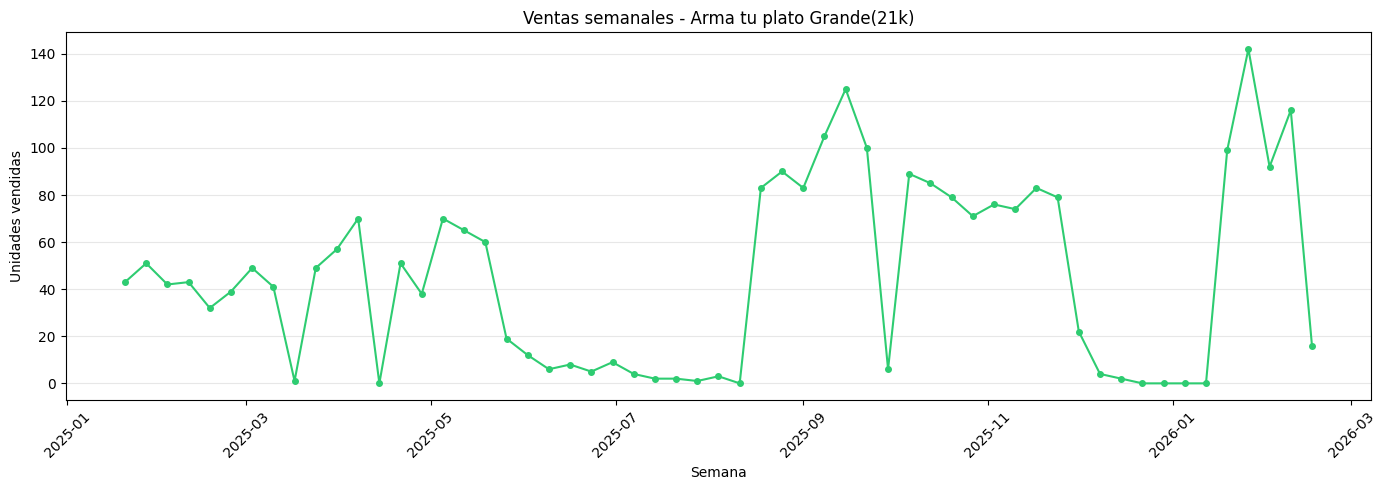

In [ ]:
import matplotlib.pyplot as plt

# Filtrar desde enero 2025
serie_grafica = serie_test[serie_test['ds'] >= '2025-01-01'].copy()

plt.figure(figsize=(14, 5))
plt.plot(serie_grafica['ds'], serie_grafica['y'], marker='o', linewidth=1.5, markersize=4, color='#2ecc71')
plt.title('Ventas semanales - Arma tu plato Grande(21k)')
plt.xlabel('Semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


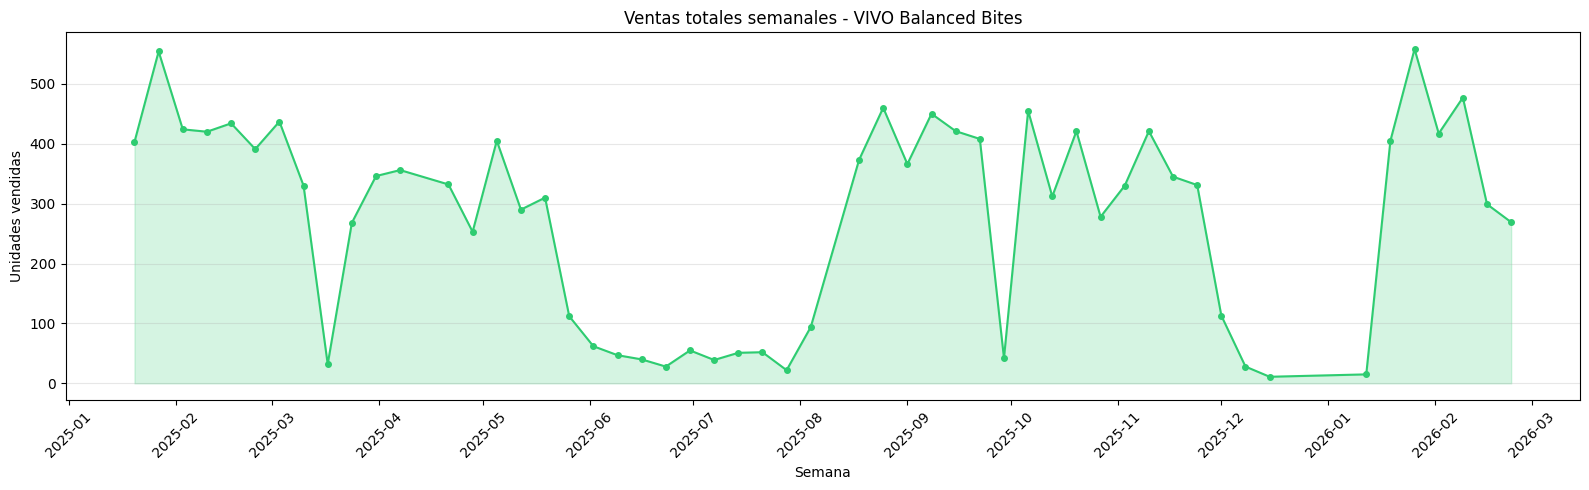

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ventas totales semanales
ventas_totales = ventas_criticas.copy()
ventas_totales['semana'] = ventas_totales['Fecha'].dt.to_period('W').dt.start_time
ventas_semanales = ventas_totales.groupby('semana')['Cantidad'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(ventas_semanales['semana'], ventas_semanales['Cantidad'], 
         linewidth=1.5, color='#2ecc71', marker='o', markersize=4)
plt.fill_between(ventas_semanales['semana'], ventas_semanales['Cantidad'], 
                 alpha=0.2, color='#2ecc71')
plt.title('Ventas totales semanales - VIVO Balanced Bites')
plt.xlabel('Semana')
plt.ylabel('Unidades vendidas')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


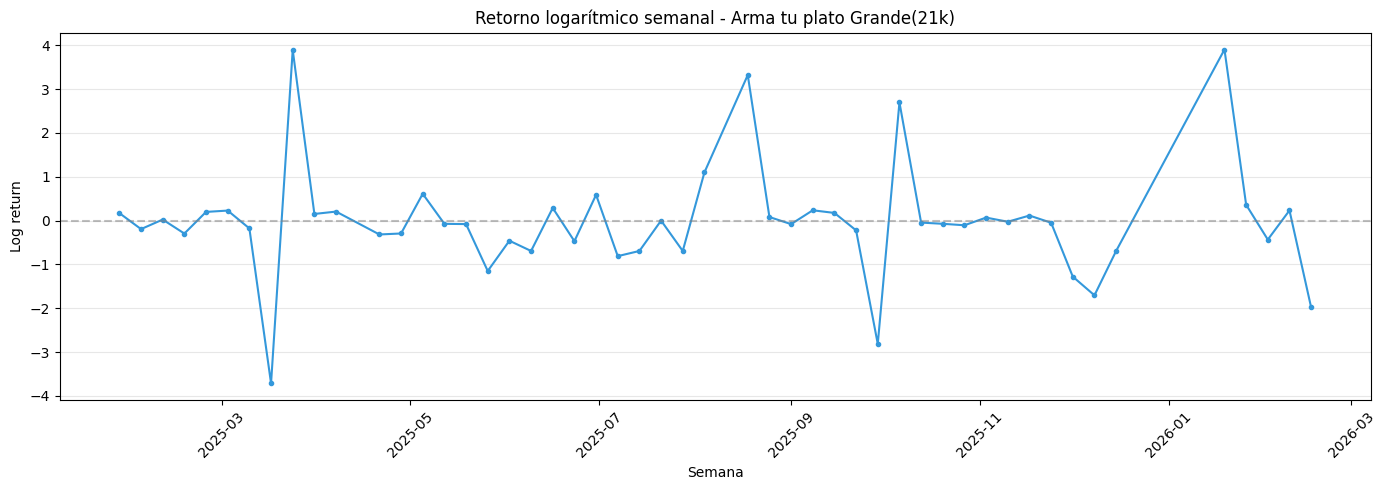

Media: -0.020
Std:   1.327


In [ ]:
import numpy as np

serie_log = serie_test[serie_test['y'] > 0].copy().reset_index(drop=True)

# Retorno logarítmico
serie_log['log_return'] = np.log(serie_log['y'] / serie_log['y'].shift(1))
serie_log = serie_log.dropna()

plt.figure(figsize=(14, 5))
plt.plot(serie_log['ds'], serie_log['log_return'], 
         linewidth=1.5, color='#3498db', marker='o', markersize=3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.title('Retorno logarítmico semanal - Arma tu plato Grande(21k)')
plt.xlabel('Semana')
plt.ylabel('Log return')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Media: {serie_log['log_return'].mean():.3f}")
print(f"Std:   {serie_log['log_return'].std():.3f}")


In [ ]:
def preparar_serie(df, nombre_producto):
    df_prod = df[df['Nombre'] == nombre_producto].copy()
    
    # Agrupar por día
    serie = df_prod.groupby('Fecha')['Cantidad'].sum().reset_index()
    
    # Renombrar al formato Prophet
    serie = serie.rename(columns={'Fecha': 'ds', 'Cantidad': 'y'})
    
    # Rellenar días sin ventas con 0
    rango = pd.date_range(serie['ds'].min(), serie['ds'].max(), freq='D')
    serie = serie.set_index('ds').reindex(rango, fill_value=0).reset_index()
    serie = serie.rename(columns={'index': 'ds'})
    
    return serie


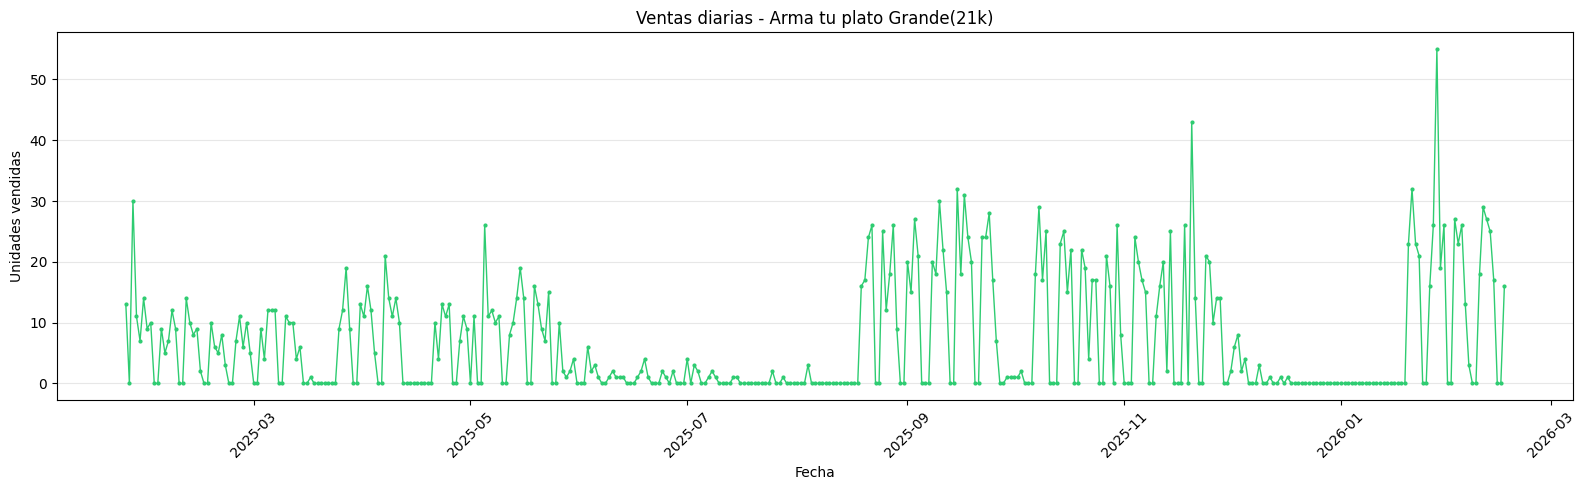

In [ ]:
import matplotlib.pyplot as plt

# Serie diaria de Arma tu plato Grande
serie_diaria = preparar_serie(ventas_criticas, 'Arma tu plato Grande(21k)')

plt.figure(figsize=(16, 5))
plt.plot(serie_diaria['ds'], serie_diaria['y'], 
         linewidth=1, color='#2ecc71', marker='o', markersize=2)
plt.title('Ventas diarias - Arma tu plato Grande(21k)')
plt.xlabel('Fecha')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
!pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 22.6 MB/s eta 0:00:05
   ---- ----------------------------------- 10.2/101.7 MB 31.9 MB/s eta 0:00:03
   -------- ------------------------------- 21.0/101.7 MB 40.2 MB/s eta 0:00:03
   ------------ --------------------------- 32.2/101.7 MB 43.6 MB/s eta 0:00:02
   ----------------- ---------------------- 44.6/101.7 MB 46.5 MB/s eta 0:00:02
   ---------------------- ----------------- 57.1/101.7 MB 49.2 MB/s eta 0:00:01
   --------------------------- ------------ 68.7/101.7 MB 49.8 MB/s eta 0:00:01
   ------------------------------- -------- 80.0/101.7 MB 50.0 MB/s eta 0:00:01
   ------------------------------------ --- 92.0/101.7 MB 51.1 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 51.0 MB/s eta 0:00:01
   ---------------------------------------- 101.7/101.7 MB 45.7 MB/s  0:00:02



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Serie diaria sin ceros
serie_xgb = preparar_serie(ventas_criticas, 'Arma tu plato Grande(21k)').copy()

# Agregar columna de vacaciones
serie_xgb['en_vacaciones'] = serie_xgb['ds'].apply(
    lambda x: 1 if vacaciones['ds'].isin([x]).any() else 0
)

# Features temporales
serie_xgb['dia_semana']    = serie_xgb['ds'].dt.dayofweek
serie_xgb['mes']           = serie_xgb['ds'].dt.month
serie_xgb['semana_anio']   = serie_xgb['ds'].dt.isocalendar().week.astype(int)
serie_xgb['es_fin_semana'] = (serie_xgb['dia_semana'] >= 5).astype(int)
serie_xgb['quincena']      = (serie_xgb['ds'].dt.day > 15).astype(int)

# Lags
serie_xgb['lag_7']  = serie_xgb['y'].shift(7)
serie_xgb['lag_14'] = serie_xgb['y'].shift(14)
serie_xgb['lag_30'] = serie_xgb['y'].shift(30)

# Rolling mean
serie_xgb['rolling_mean_7'] = serie_xgb['y'].shift(1).rolling(7).mean()

# Prophet pred como feature
prophet_indexed = forecast_test.set_index('ds')['yhat']
serie_xgb['prophet_pred'] = serie_xgb['ds'].map(prophet_indexed)

# Eliminar filas con NaN
serie_xgb = serie_xgb.dropna().reset_index(drop=True)

print(serie_xgb.shape)
serie_xgb.head()


(52, 13)


,ds,y,en_vacaciones,dia_semana,mes,semana_anio,es_fin_semana,quincena,lag_7,lag_14,lag_30,rolling_mean_7,prophet_pred
0,2025-02-24,7.0,0,0,2,9,0,1,10.0,14.0,0.0,4.571429,22.0
1,2025-03-03,9.0,0,0,3,10,0,0,7.0,10.0,0.0,5.571429,35.0
2,2025-03-10,11.0,0,0,3,11,0,0,9.0,7.0,0.0,7.000000,52.0
3,2025-03-17,1.0,1,0,3,12,0,1,11.0,9.0,0.0,5.857143,4.0
4,2025-03-24,0.0,0,0,3,13,0,1,1.0,11.0,0.0,0.142857,49.0


In [ ]:
# Features y target
features = ['dia_semana', 'mes', 'semana_anio', 'es_fin_semana', 
            'quincena', 'lag_7', 'lag_14', 'lag_30', 
            'rolling_mean_7', 'prophet_pred', 'en_vacaciones']

X = serie_xgb[features]
y = serie_xgb['y']

# Split temporal — 80% train, 20% test
split = int(len(serie_xgb) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} filas")
print(f"Test:  {len(X_test)} filas")

# Entrenar XGBoost
modelo_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
modelo_xgb.fit(X_train, y_train)

# Predicciones
y_pred = modelo_xgb.predict(X_test)
y_pred = np.clip(y_pred, 0, None).round(0)

# SMAPE
def smape(real, pred):
    return np.mean(2 * np.abs(pred - real) / (np.abs(real) + np.abs(pred) + 1e-8))

smape_xgb = smape(y_test.values, y_pred)
mae_xgb   = mean_absolute_error(y_test, y_pred)

print(f"\nSMAPE XGBoost: {smape_xgb:.3f}")
print(f"MAE XGBoost:   {mae_xgb:.1f}")
print(f"\nSMAPE Prophet: 1.332")
print(f"Mejora:        {((1.332 - smape_xgb) / 1.332 * 100):.1f}%")


Train: 41 filas
Test:  11 filas

SMAPE XGBoost: 1.195
MAE XGBoost:   3.6

SMAPE Prophet: 1.332
Mejora:        10.3%


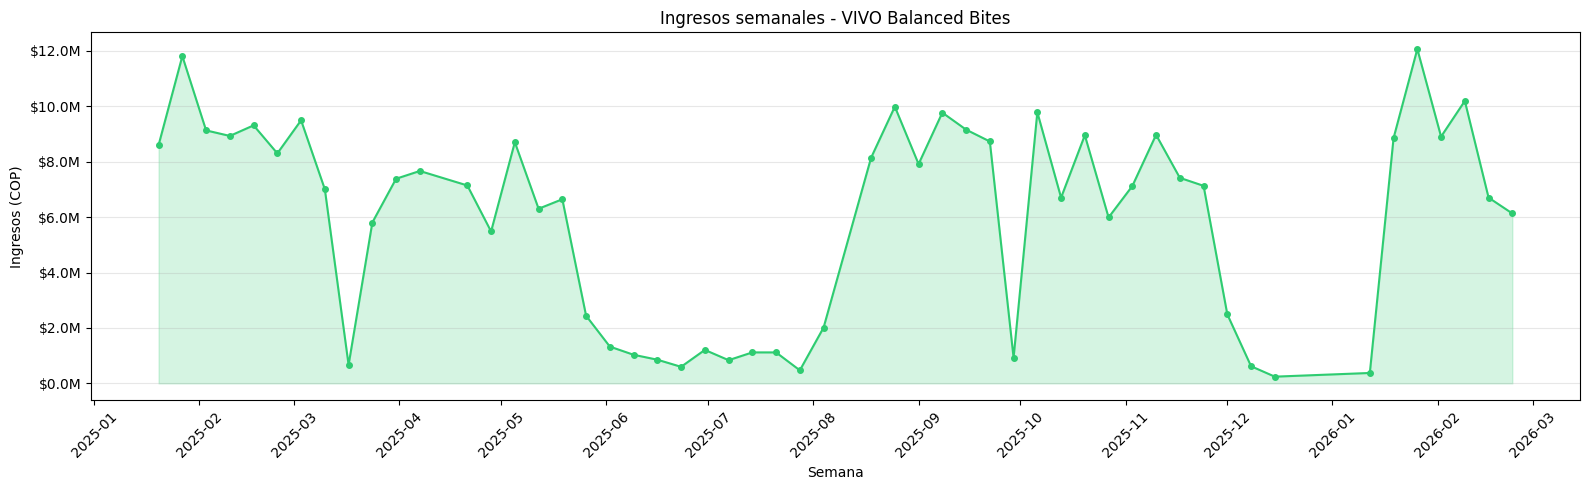

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ventas totales semanales por plata
ventas_plata = ventas_criticas.copy()
ventas_plata['semana'] = ventas_plata['Fecha'].dt.to_period('W').dt.start_time
ventas_semanales_plata = ventas_plata.groupby('semana')['Total'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(ventas_semanales_plata['semana'], ventas_semanales_plata['Total'], 
         linewidth=1.5, color='#2ecc71', marker='o', markersize=4)
plt.fill_between(ventas_semanales_plata['semana'], ventas_semanales_plata['Total'], 
                 alpha=0.2, color='#2ecc71')
plt.title('Ingresos semanales - VIVO Balanced Bites')
plt.xlabel('Semana')
plt.ylabel('Ingresos (COP)')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


*Verificar los datos del clima*

In [ ]:
import requests
import pandas as pd

# Coordenadas de Bogotá
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 4.6097,
    "longitude": -74.0817,
    "start_date": "2025-01-01",
    "end_date": "2026-02-16",
    "daily": ["precipitation_sum", "temperature_2m_mean"],
    "timezone": "America/Bogota"
}

response = requests.get(url, params=params)
clima = pd.DataFrame(response.json()['daily'])
clima['time'] = pd.to_datetime(clima['time'])
clima = clima.rename(columns={
    'time': 'Fecha',
    'precipitation_sum': 'lluvia_mm',
    'temperature_2m_mean': 'temperatura'
})

print(clima.shape)
clima.head()


(412, 3)


,Fecha,lluvia_mm,temperatura
0,2025-01-01,0.7,14.1
1,2025-01-02,0.9,14.7
2,2025-01-03,15.3,13.7
3,2025-01-04,15.0,13.7
4,2025-01-05,1.3,13.4


*Preparar serie de ingresos mensuales*

In [ ]:
# Serie semanal de ingresos totales
ingresos_semanales = ventas_criticas.copy()
ingresos_semanales['semana'] = ingresos_semanales['Fecha'].dt.to_period('W').dt.start_time
ingresos_semanales = ingresos_semanales.groupby('semana')['Total'].sum().reset_index()
ingresos_semanales = ingresos_semanales.rename(columns={'semana': 'ds', 'Total': 'y'})

# Rellenar semanas sin ventas con 0
rango = pd.date_range(ingresos_semanales['ds'].min(), ingresos_semanales['ds'].max(), freq='W-MON')
ingresos_semanales = ingresos_semanales.set_index('ds').reindex(rango, fill_value=0).reset_index()
ingresos_semanales = ingresos_semanales.rename(columns={'index': 'ds'})

print(f"Semanas totales: {len(ingresos_semanales)}")
print(f"Semanas con ventas: {(ingresos_semanales['y'] > 0).sum()}")
ingresos_semanales.head()


Semanas totales: 58
Semanas con ventas: 53


,ds,y
0,2025-01-20,8599700.0
1,2025-01-27,11810450.0
2,2025-02-03,9128951.0
3,2025-02-10,8929200.0
4,2025-02-17,9310600.0


*Agrupar todos los datos*

In [ ]:
# Agrupar clima por semana
clima['semana'] = clima['Fecha'].dt.to_period('W').dt.start_time
clima_semanal = clima.groupby('semana').agg(
    lluvia_total  = ('lluvia_mm', 'sum'),
    dias_lluvia   = ('lluvia_mm', lambda x: (x > 5).sum()),
    temperatura   = ('temperatura', 'mean')
).reset_index()
clima_semanal = clima_semanal.rename(columns={'semana': 'ds'})

# Merge con serie de ingresos
xgb_ingresos = ingresos_semanales.copy()
xgb_ingresos = xgb_ingresos.merge(clima_semanal, on='ds', how='left')

# Vacaciones
xgb_ingresos['en_vacaciones'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if vacaciones['ds'].isin([x]).any() else 0
)

# Features temporales
xgb_ingresos['mes']         = xgb_ingresos['ds'].dt.month
xgb_ingresos['semana_anio'] = xgb_ingresos['ds'].dt.isocalendar().week.astype(int)
xgb_ingresos['quincena']    = (xgb_ingresos['ds'].dt.day > 15).astype(int)
xgb_ingresos['dia_pago']    = xgb_ingresos['ds'].dt.day.isin(range(13,17)).astype(int)

# Inicio de semestre (primeras 2 semanas de clases)
inicios_semestre = pd.to_datetime(['2025-01-20', '2025-08-04', '2026-01-19'])
xgb_ingresos['inicio_semestre'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if any(abs((x - i).days) <= 14 for i in inicios_semestre) else 0
)

# Semana de evaluaciones
eval_fechas = pd.to_datetime(['2025-05-05', '2025-11-10', '2026-05-04', '2026-11-09'])
xgb_ingresos['semana_evaluaciones'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if any(abs((x - e).days) <= 7 for e in eval_fechas) else 0
)

# Semana de exámenes finales
examenes_fechas = pd.to_datetime(['2025-05-26', '2025-12-01', '2026-05-25', '2026-11-30'])
xgb_ingresos['semana_examenes'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if any(abs((x - e).days) <= 7 for e in examenes_fechas) else 0
)

# Lags
xgb_ingresos['lag_1'] = xgb_ingresos['y'].shift(1)
xgb_ingresos['lag_2'] = xgb_ingresos['y'].shift(2)
xgb_ingresos['lag_4'] = xgb_ingresos['y'].shift(4)

# Rolling mean
xgb_ingresos['rolling_mean_4'] = xgb_ingresos['y'].shift(1).rolling(4).mean()

# Prophet pred
prophet_idx = forecast_ingresos.set_index('ds')['yhat']
xgb_ingresos['prophet_pred'] = xgb_ingresos['ds'].map(prophet_idx)

# Eliminar NaN
xgb_ingresos = xgb_ingresos.dropna().reset_index(drop=True)

print(f"Shape: {xgb_ingresos.shape}")
print(f"Columnas: {xgb_ingresos.columns.tolist()}")


Shape: (53, 18)
Columnas: ['ds', 'y', 'lluvia_total', 'dias_lluvia', 'temperatura', 'en_vacaciones', 'mes', 'semana_anio', 'quincena', 'dia_pago', 'inicio_semestre', 'semana_evaluaciones', 'semana_examenes', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'prophet_pred']


*Entrenar prophet*

In [101]:
modelo_ingresos = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    holidays=vacaciones,
    changepoint_prior_scale=0.05,
    holidays_prior_scale=10.0
)

modelo_ingresos.add_country_holidays(country_name='CO')
modelo_ingresos.fit(ingresos_semanales)

futuro = modelo_ingresos.make_future_dataframe(periods=4, freq='W')
forecast_ingresos = modelo_ingresos.predict(futuro)

forecast_ingresos['yhat']       = forecast_ingresos['yhat'].clip(lower=0).round(0)
forecast_ingresos['yhat_lower'] = forecast_ingresos['yhat_lower'].clip(lower=0).round(0)
forecast_ingresos['yhat_upper'] = forecast_ingresos['yhat_upper'].clip(lower=0).round(0)

forecast_ingresos[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(4)


19:18:33 - cmdstanpy - INFO - Chain [1] start processing
19:18:34 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
58,2026-03-01,7580853.0,6175437.0,9023566.0
59,2026-03-08,7959273.0,6521925.0,9338862.0
60,2026-03-15,8282193.0,6822844.0,9602645.0
61,2026-03-22,8307992.0,6936581.0,9769413.0


*cross validation Prophet:*

In [106]:
n_semanas = len(ingresos_semanales)

cv_ingresos = cross_validation(
    modelo_ingresos,
    initial=f'{int(n_semanas * 0.6) * 7} days',
    period='14 days',
    horizon='28 days'
)

metricas_ingresos = performance_metrics(cv_ingresos)
print(metricas_ingresos[['horizon', 'smape', 'rmse', 'mae']].tail(5))


Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/10 [00:00<?, ?it/s]

19:20:00 - cmdstanpy - INFO - Chain [1] start processing
19:20:02 - cmdstanpy - INFO - Chain [1] done processing
19:20:02 - cmdstanpy - INFO - Chain [1] start processing
19:20:04 - cmdstanpy - INFO - Chain [1] done processing
19:20:04 - cmdstanpy - INFO - Chain [1] start processing
19:20:05 - cmdstanpy - INFO - Chain [1] done processing
19:20:05 - cmdstanpy - INFO - Chain [1] start processing
19:20:05 - cmdstanpy - INFO - Chain [1] done processing
19:20:05 - cmdstanpy - INFO - Chain [1] start processing
19:20:06 - cmdstanpy - INFO - Chain [1] done processing
19:20:06 - cmdstanpy - INFO - Chain [1] start processing
19:20:06 - cmdstanpy - INFO - Chain [1] done processing
19:20:07 - cmdstanpy - INFO - Chain [1] start processing
19:20:07 - cmdstanpy - INFO - Chain [1] done processing
19:20:08 - cmdstanpy - INFO - Chain [1] start processing
19:20:08 - cmdstanpy - INFO - Chain [1] done processing
19:20:08 - cmdstanpy - INFO - Chain [1] start processing
19:20:09 - cmdstanpy - INFO - Chain [1]

  horizon     smape          rmse           mae
0  7 days  1.392329  1.834495e+07  1.449890e+07
1 14 days  1.534447  6.007120e+07  3.943229e+07
2 21 days  1.541759  1.269625e+08  7.722111e+07
3 28 days  1.583761  1.832741e+08  1.126970e+08


*Construir features para XGBOOST*

In [103]:
# Copiar serie
xgb_ingresos = ingresos_semanales.copy()

# Vacaciones
xgb_ingresos['en_vacaciones'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if vacaciones['ds'].isin([x]).any() else 0
)

# Features temporales
xgb_ingresos['mes']         = xgb_ingresos['ds'].dt.month
xgb_ingresos['semana_anio'] = xgb_ingresos['ds'].dt.isocalendar().week.astype(int)
xgb_ingresos['quincena']    = (xgb_ingresos['ds'].dt.day > 15).astype(int)

# Lags
xgb_ingresos['lag_1']  = xgb_ingresos['y'].shift(1)
xgb_ingresos['lag_2']  = xgb_ingresos['y'].shift(2)
xgb_ingresos['lag_4']  = xgb_ingresos['y'].shift(4)

# Rolling mean
xgb_ingresos['rolling_mean_4'] = xgb_ingresos['y'].shift(1).rolling(4).mean()

# Prophet pred como feature
prophet_idx = forecast_ingresos.set_index('ds')['yhat']
xgb_ingresos['prophet_pred'] = xgb_ingresos['ds'].map(prophet_idx)

# Eliminar NaN
xgb_ingresos = xgb_ingresos.dropna().reset_index(drop=True)

print(f"Shape: {xgb_ingresos.shape}")
xgb_ingresos.head()


Shape: (54, 11)


,ds,y,en_vacaciones,mes,semana_anio,quincena,lag_1,lag_2,lag_4,rolling_mean_4,prophet_pred
0,2025-02-17,9310600.0,0,2,8,1,8929200.0,9128951.0,8599700.0,9617075.25,8010753.0
1,2025-02-24,8299600.0,0,2,9,1,9310600.0,8929200.0,11810450.0,9794800.25,7824159.0
2,2025-03-03,9493050.0,0,3,10,0,8299600.0,9310600.0,9128951.0,8917087.75,8144616.0
3,2025-03-10,7004700.0,0,3,11,0,9493050.0,8299600.0,8929200.0,9008112.50,8543226.0
4,2025-03-17,665000.0,1,3,12,1,7004700.0,9493050.0,9310600.0,8526987.50,249086.0


*Nuevos features XGBOOST*

In [ ]:
# Agregar clima
clima['semana'] = clima['Fecha'].dt.to_period('W').dt.start_time
clima_semanal = clima.groupby('semana').agg(
    lluvia_total  = ('lluvia_mm', 'sum'),
    dias_lluvia   = ('lluvia_mm', lambda x: (x > 5).sum()),
    temperatura   = ('temperatura', 'mean')
).reset_index()
clima_semanal = clima_semanal.rename(columns={'semana': 'ds'})
xgb_ingresos = xgb_ingresos.merge(clima_semanal, on='ds', how='left')

# Día de pago
xgb_ingresos['dia_pago'] = xgb_ingresos['ds'].dt.day.isin(range(13, 17)).astype(int)

# Inicio semestre
inicios_semestre = pd.to_datetime(['2025-01-20', '2025-08-04', '2026-01-19'])
xgb_ingresos['inicio_semestre'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if any(abs((x - i).days) <= 14 for i in inicios_semestre) else 0
)

# Semana evaluaciones
eval_fechas = pd.to_datetime(['2025-05-05', '2025-11-10', '2026-05-04'])
xgb_ingresos['semana_evaluaciones'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if any(abs((x - e).days) <= 7 for e in eval_fechas) else 0
)

# Semana exámenes
examenes_fechas = pd.to_datetime(['2025-05-26', '2025-12-01', '2026-05-25'])
xgb_ingresos['semana_examenes'] = xgb_ingresos['ds'].apply(
    lambda x: 1 if any(abs((x - e).days) <= 7 for e in examenes_fechas) else 0
)

# Eliminar NaN del merge
xgb_ingresos = xgb_ingresos.dropna().reset_index(drop=True)

print(f"Shape: {xgb_ingresos.shape}")
print(xgb_ingresos.columns.tolist())


Shape: (53, 18)
['ds', 'y', 'en_vacaciones', 'mes', 'semana_anio', 'quincena', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4', 'prophet_pred', 'lluvia_total', 'dias_lluvia', 'temperatura', 'dia_pago', 'inicio_semestre', 'semana_evaluaciones', 'semana_examenes']


*entrenar XGBoost:*

In [108]:
features = [
    'mes', 'semana_anio', 'quincena', 'dia_pago',
    'en_vacaciones', 'inicio_semestre', 
    'semana_evaluaciones', 'semana_examenes',
    'lluvia_total', 'dias_lluvia', 'temperatura',
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4', 'prophet_pred'
]

X = xgb_ingresos[features]
y = xgb_ingresos['y']

split = int(len(xgb_ingresos) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} semanas")
print(f"Test:  {len(X_test)} semanas")

modelo_xgb_ingresos = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
modelo_xgb_ingresos.fit(X_train, y_train)

y_pred = modelo_xgb_ingresos.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

smape_xgb = smape(y_test.values, y_pred)
mae_xgb   = mean_absolute_error(y_test, y_pred)

print(f"\nSMAPE anterior: 0.848")
print(f"SMAPE nuevo:    {smape_xgb:.3f}")
print(f"MAE:            ${mae_xgb/1e6:.2f}M")
print(f"Mejora:         {((0.848 - smape_xgb) / 0.848 * 100):.1f}%")


Train: 42 semanas
Test:  11 semanas

SMAPE anterior: 0.848
SMAPE nuevo:    0.845
MAE:            $1.47M
Mejora:         0.4%


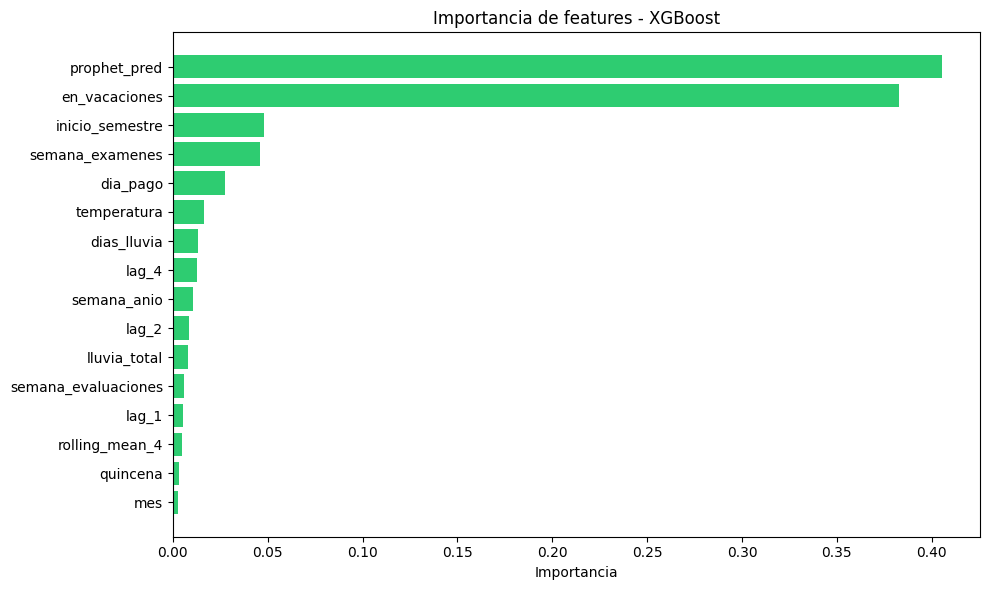

                feature  importancia
15         prophet_pred     0.405219
4         en_vacaciones     0.383028
5       inicio_semestre     0.047816
7       semana_examenes     0.046088
3              dia_pago     0.027420
10          temperatura     0.016169
9           dias_lluvia     0.013000
13                lag_4     0.012610
1           semana_anio     0.010592
12                lag_2     0.008426
8          lluvia_total     0.007836
6   semana_evaluaciones     0.006067
11                lag_1     0.005198
14       rolling_mean_4     0.004901
2              quincena     0.003084
0                   mes     0.002547


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.DataFrame({
    'feature': features,
    'importancia': modelo_xgb_ingresos.feature_importances_
}).sort_values('importancia', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importancias['feature'], importancias['importancia'], color='#2ecc71')
plt.title('Importancia de features - XGBoost')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print(importancias.sort_values('importancia', ascending=False))
